# 🚀 Rocket Launch Pad Predictive Maintenance
### 24CY731 – DMML Mini Project
**Team:** R Yogeshwari (CB.SC.P2CYS25022) | Kanaganandini Kanagaraj (CB.SC.P2CYS25011)

---

## Domain Adaptation Rationale

Real-world sensor data from rocket launch pads (ISRO, NASA) is classified and not publicly available.
The **AI4I 2020 Predictive Maintenance Dataset** (UCI) is the widely accepted benchmark for industrial
predictive-maintenance research.
Its failure modes map directly onto rocket launch pad subsystems as follows:

| AI4I Failure Mode | Code | Rocket Pad Analog |
|---|---|---|
| Tool Wear Failure | TWF | Actuator / valve mechanical degradation |
| Heat Dissipation Failure | HDF | Thermal Protection System (TPS) fault |
| Power Failure | PWF | Hydraulic / pneumatic pressure loss |
| Overstrain Failure | OSF | Structural overload / mount fatigue |
| Random Failure | RNF | Stochastic electrical / sensor fault |



**Models:** Random Forest · XGBoost · LightGBM · LSTM · Autoencoder · RUL Regression · **Stacking Ensemble (Novel)**

**Explainability:** SHAP · Optimal Threshold Tuning · Multi-Fault Classification


##1 - Install & Import Libraries

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap torch optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, accuracy_score, roc_auc_score,
    roc_curve, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
import xgboost as xgb
import lightgbm as lgb
import shap

print("All libraries imported successfully ✓")
print(f"PyTorch version: {torch.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.9 MB/s eta 0:00:00
All libraries imported successfully ✓
PyTorch version: 2.10.0+cpu


##2 - Load Dataset

In [ ]:
# Download from: https://archive.ics.uci.edu/ml/datasets/AI4I+2020+Predictive+Maintenance+Dataset
# Upload ai4i2020.csv to Colab before running

ai4i = pd.read_csv('/content/ai4i2020.csv')

print('Shape:', ai4i.shape)
print()
print('Columns:', ai4i.columns.tolist())
print()
print('Class distribution (Machine failure):')
print(ai4i['Machine failure'].value_counts())
print(f"  Failure rate: {ai4i['Machine failure'].mean()*100:.2f}%")
print()
ai4i.head()


Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Class distribution (Machine failure):
Machine failure
0    9661
1     339
Name: count, dtype: int64
  Failure rate: 3.39%



,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


##3 - Clean & Prepare Data

In [ ]:
ai4i.columns = (
    ai4i.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
    .str.replace(' ', '_', regex=False)
)

# --- Drop ID columns ---
ai4i = ai4i.drop(columns=['UDI', 'Product_ID'], errors='ignore')

# --- Encode Type column ---
ai4i['Type'] = LabelEncoder().fit_transform(ai4i['Type'])

# --- Define binary target (Machine failure) ---
y = ai4i['Machine_failure'].copy()

# --- Define fault-type target (multi-label → dominant fault) ---
fault_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
# For multi-fault model: use fault columns directly
y_fault = ai4i[fault_cols].copy()

# --- Feature matrix ---
drop_cols = ['Machine_failure'] + fault_cols
X = ai4i.drop(columns=drop_cols)

print('Feature columns:', X.columns.tolist())
print('X shape:', X.shape)
print('y (binary) distribution:')
print(y.value_counts())

# --- Scale features ---
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# --- Train/test split (stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print()
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Failures in test set: {y_test.sum()} / {len(y_test)}')


Feature columns: ['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']
X shape: (10000, 6)
y (binary) distribution:
Machine_failure
0    9661
1     339
Name: count, dtype: int64

Train size: 8000 | Test size: 2000
Failures in test set: 68 / 2000


##4 - Exploratory Data Analysis (EDA)

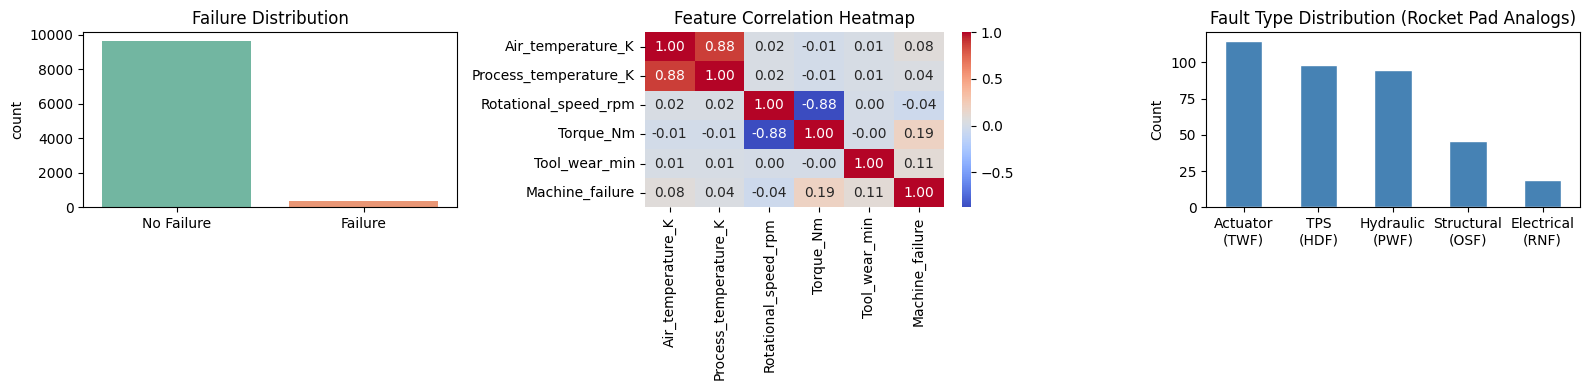


Descriptive statistics:


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min
count,10000.0,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95
std,2.0,1.48,179.28,9.97,63.65
min,295.3,305.70,1168.00,3.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.80,162.00
max,304.5,313.80,2886.00,76.60,253.00


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

#Failure distribution
sns.countplot(x=y, ax=axes[0], palette='Set2')
axes[0].set_title('Failure Distribution')
axes[0].set_xticklabels(['No Failure', 'Failure'])
axes[0].set_xlabel('')

#Correlation heatmap of numeric features
num_cols = ['Air_temperature_K', 'Process_temperature_K',
            'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']

corr = ai4i[num_cols + ['Machine_failure']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap')

#Fault type breakdown (rocket pad analogy)
fault_counts = ai4i[fault_cols].sum().sort_values(ascending=False)

fault_counts.index = ['Actuator\n(TWF)',
                      'TPS\n(HDF)',
                      'Hydraulic\n(PWF)',
                      'Structural\n(OSF)',
                      'Electrical\n(RNF)']

fault_counts.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Fault Type Distribution (Rocket Pad Analogs)')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

#Layout & display
plt.tight_layout()
plt.show()

#Descriptive statistics
print("\nDescriptive statistics:")
display(ai4i[num_cols].describe().round(2))

##5 - Random Forest (with Cross-Validation)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

# --- Stratified 5-Fold Cross Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_auc  = cross_val_score(rf, X_scaled, y, cv=cv, scoring='roc_auc')
rf_cv_f1   = cross_val_score(rf, X_scaled, y, cv=cv, scoring='f1')

print('=== Random Forest — Cross-Validation ===')
print(f'  ROC-AUC : {rf_cv_auc.mean():.4f} ± {rf_cv_auc.std():.4f}')
print(f'  F1      : {rf_cv_f1.mean():.4f} ± {rf_cv_f1.std():.4f}')

# --- Final fit on train split ---
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs  = rf.predict_proba(X_test)[:, 1]

print()
print('=== Random Forest — Test Set ===')
print(classification_report(y_test, rf_preds, target_names=['No Failure', 'Failure']))
print(f'ROC-AUC (test): {roc_auc_score(y_test, rf_probs):.4f}')


=== Random Forest — Cross-Validation ===
  ROC-AUC : 0.9698 ± 0.0054
  F1      : 0.6303 ± 0.0565

=== Random Forest — Test Set ===
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.68      0.69      0.69        68

    accuracy                           0.98      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC (test): 0.9713


##6 - XGBoost (with Cross-Validation)

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=int((y == 0).sum() / (y == 1).sum()),
    eval_metric='logloss',
    random_state=42
)

xgb_cv_auc = cross_val_score(xgb_model, X_scaled, y, cv=cv, scoring='roc_auc')
xgb_cv_f1  = cross_val_score(xgb_model, X_scaled, y, cv=cv, scoring='f1')

print('=== XGBoost — Cross-Validation ===')
print(f'  ROC-AUC : {xgb_cv_auc.mean():.4f} ± {xgb_cv_auc.std():.4f}')
print(f'  F1      : {xgb_cv_f1.mean():.4f} ± {xgb_cv_f1.std():.4f}')

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_probs  = xgb_model.predict_proba(X_test)[:, 1]

print()
print('=== XGBoost — Test Set ===')
print(classification_report(y_test, xgb_preds, target_names=['No Failure', 'Failure']))
print(f'ROC-AUC (test): {roc_auc_score(y_test, xgb_probs):.4f}')


=== XGBoost — Cross-Validation ===
  ROC-AUC : 0.9738 ± 0.0039
  F1      : 0.7224 ± 0.0231

=== XGBoost — Test Set ===
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.72      0.79      0.76        68

    accuracy                           0.98      2000
   macro avg       0.86      0.89      0.87      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC (test): 0.9716


##7 - LightGBM (with Cross-Validation)

In [ ]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

lgb_cv_auc = cross_val_score(lgb_model, X_scaled, y, cv=cv, scoring='roc_auc')
lgb_cv_f1  = cross_val_score(lgb_model, X_scaled, y, cv=cv, scoring='f1')

print('=== LightGBM — Cross-Validation ===')
print(f'  ROC-AUC : {lgb_cv_auc.mean():.4f} ± {lgb_cv_auc.std():.4f}')
print(f'  F1      : {lgb_cv_f1.mean():.4f} ± {lgb_cv_f1.std():.4f}')

lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
lgb_probs  = lgb_model.predict_proba(X_test)[:, 1]

print()
print('=== LightGBM — Test Set ===')
print(classification_report(y_test, lgb_preds, target_names=['No Failure', 'Failure']))
print(f'ROC-AUC (test): {roc_auc_score(y_test, lgb_probs):.4f}')


=== LightGBM — Cross-Validation ===
  ROC-AUC : 0.9708 ± 0.0064
  F1      : 0.7046 ± 0.0199

=== LightGBM — Test Set ===
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.69      0.79      0.74        68

    accuracy                           0.98      2000
   macro avg       0.84      0.89      0.86      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC (test): 0.9691


##8 - LSTM

In [ ]:
SEQ_LEN = 10

def create_sequences(X_df, y_series, seq_len):
    """Build overlapping sliding windows of length seq_len."""
    xs, ys = [], []
    X_arr = X_df.values
    y_arr = y_series.values
    for i in range(len(X_arr) - seq_len):
        xs.append(X_arr[i : i + seq_len])
        ys.append(y_arr[i + seq_len])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_seq_train, y_seq_train = create_sequences(X_train, y_train, SEQ_LEN)
X_seq_test,  y_seq_test  = create_sequences(X_test,  y_test,  SEQ_LEN)

print(f'LSTM train: {X_seq_train.shape} | test: {X_seq_test.shape}')

# --- Build DataLoaders ---
train_ds = TensorDataset(torch.tensor(X_seq_train), torch.tensor(y_seq_train))
test_ds  = TensorDataset(torch.tensor(X_seq_test),  torch.tensor(y_seq_test))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=64)

# --- LSTM model ---
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden=64, layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
lstm = LSTMClassifier(X_seq_train.shape[2]).to(device)
opt  = torch.optim.Adam(lstm.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

# --- Training loop ---
for epoch in range(30):
    lstm.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss_fn(lstm(xb), yb).backward()
        opt.step()
    if (epoch+1) % 10 == 0:
        print(f'  Epoch {epoch+1}/30 done')

# --- Evaluation ---
lstm.eval()
lstm_probs_list = []
with torch.no_grad():
    for xb, _ in test_dl:
        lstm_probs_list.append(lstm(xb.to(device)).cpu().numpy())
lstm_probs = np.concatenate(lstm_probs_list)
lstm_preds = (lstm_probs >= 0.5).astype(int)

print()
print('=== LSTM — Test Set ===')
print(classification_report(y_seq_test.astype(int), lstm_preds,
                             target_names=['No Failure', 'Failure']))
print(f'ROC-AUC: {roc_auc_score(y_seq_test, lstm_probs):.4f}')


LSTM train: (7990, 10, 6) | test: (1990, 10, 6)
  Epoch 10/30 done
  Epoch 20/30 done
  Epoch 30/30 done

=== LSTM — Test Set ===
              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.98      1922
     Failure       0.00      0.00      0.00        68

    accuracy                           0.97      1990
   macro avg       0.48      0.50      0.49      1990
weighted avg       0.93      0.97      0.95      1990

ROC-AUC: 0.4710


##9 - Autoencoder (Anomaly Detection)

In [ ]:
# Trained ONLY on normal (no-failure) samples.
# High reconstruction error → anomaly (failure).

X_normal_train = X_train[y_train == 0]

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8),         nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),          nn.ReLU(),
            nn.Linear(16, input_dim),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

ae = Autoencoder(X_train.shape[1]).to(device)
ae_opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
ae_loss_fn = nn.MSELoss()

X_norm_t = torch.tensor(X_normal_train.values, dtype=torch.float32)
ae_ds = DataLoader(TensorDataset(X_norm_t), batch_size=64, shuffle=True)

for epoch in range(40):
    ae.train()
    for (xb,) in ae_ds:
        xb = xb.to(device)
        ae_opt.zero_grad()
        ae_loss_fn(ae(xb), xb).backward()
        ae_opt.step()
    if (epoch+1) % 20 == 0:
        print(f'  Autoencoder epoch {epoch+1}/40 done')

# --- Compute reconstruction errors on test set ---
ae.eval()
X_test_t = torch.tensor(X_test.values, dtype=torch.float32).to(device)
with torch.no_grad():
    recon = ae(X_test_t).cpu().numpy()
recon_errors = np.mean((X_test.values - recon) ** 2, axis=1)

# --- Threshold: 95th percentile of normal reconstruction error ---
X_train_t = torch.tensor(X_normal_train.values, dtype=torch.float32).to(device)
with torch.no_grad():
    recon_normal = ae(X_train_t).cpu().numpy()
normal_errors = np.mean((X_normal_train.values - recon_normal) ** 2, axis=1)
ae_threshold  = np.percentile(normal_errors, 95)

ae_preds  = (recon_errors > ae_threshold).astype(int)
ae_probs  = recon_errors / recon_errors.max()   # normalised score

print()
print(f'Autoencoder threshold (95th pct): {ae_threshold:.6f}')
print()
print('=== Autoencoder — Test Set ===')
print(classification_report(y_test, ae_preds, target_names=['No Failure', 'Failure']))
print(f'ROC-AUC: {roc_auc_score(y_test, ae_probs):.4f}')


  Autoencoder epoch 20/40 done
  Autoencoder epoch 40/40 done

Autoencoder threshold (95th pct): 0.000008

=== Autoencoder — Test Set ===
              precision    recall  f1-score   support

  No Failure       0.97      0.95      0.96      1932
     Failure       0.16      0.26      0.20        68

    accuracy                           0.93      2000
   macro avg       0.57      0.61      0.58      2000
weighted avg       0.95      0.93      0.94      2000

ROC-AUC: 0.6947


## Cell 10 — RUL Regression (Time-to-Next-Failure)

In [ ]:
# RUL[i] = index of next failure after row i - i
# Represents: how many time steps until the next failure event.
# Maps to rocket pad analog: cycles remaining before next inspection.

ai4i_reset = ai4i.reset_index(drop=True)
failure_indices = ai4i_reset[ai4i_reset['Machine_failure'] == 1].index.tolist()

rul_values = []
for i in range(len(ai4i_reset)):
    future_failures = [f for f in failure_indices if f > i]
    if future_failures:
        rul_values.append(future_failures[0] - i)
    else:
        rul_values.append(len(ai4i_reset) - i)

ai4i_reset['RUL'] = rul_values

# Features for RUL (same as classification, excluding targets)
X_rul = ai4i_reset.drop(columns=['Machine_failure'] + fault_cols + ['RUL'])
y_rul = ai4i_reset['RUL']

X_rul_scaled = scaler.fit_transform(X_rul)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_rul_scaled, y_rul, test_size=0.2, random_state=42
)

from sklearn.ensemble import GradientBoostingRegressor
rul_model = GradientBoostingRegressor(
    n_estimators=300, max_depth=5,
    learning_rate=0.05, random_state=42
)
rul_model.fit(Xr_train, yr_train)
rul_preds = rul_model.predict(Xr_test)

print('=== RUL Regression (Time-to-Next-Failure) ===')
print(f'  MAE  : {mean_absolute_error(yr_test, rul_preds):.2f} steps')
print(f'  RMSE : {mean_squared_error(yr_test, rul_preds, squared=False):.2f} steps')
print(f'  R²   : {r2_score(yr_test, rul_preds):.4f}')

plt.figure(figsize=(8, 4))
plt.scatter(yr_test[:300], rul_preds[:300], alpha=0.4, s=15, color='steelblue')
plt.plot([yr_test.min(), yr_test.max()],
         [yr_test.min(), yr_test.max()], 'r--', lw=1.5, label='Perfect prediction')
plt.xlabel('Actual RUL (steps)')
plt.ylabel('Predicted RUL (steps)')
plt.title('RUL Regression — Predicted vs Actual (first 300 test samples)')
plt.legend()
plt.tight_layout()
plt.show()


##11 - Optimal Threshold Tuning

In [ ]:
# Default 0.5 threshold is sub-optimal for ~3.4% failure rate.
thresholds = np.arange(0.05, 0.95, 0.01)

def best_threshold(y_true, probs):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(y_true, (probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

models_probs = {
    'Random Forest' : rf_probs,
    'XGBoost'       : xgb_probs,
    'LightGBM'      : lgb_probs,
}

print('=== Optimal Threshold per Model ===')
print(f'{"Model":<20} {"Default F1":>12} {"Optimal T":>10} {"Optimal F1":>12}')
print('-' * 60)

optimal_thresholds = {}
for name, probs in models_probs.items():
    default_f1 = f1_score(y_test, (probs >= 0.5).astype(int), zero_division=0)
    opt_t, opt_f1 = best_threshold(y_test, probs)
    optimal_thresholds[name] = opt_t
    print(f'{name:<20} {default_f1:>12.4f} {opt_t:>10.2f} {opt_f1:>12.4f}')

# --- Re-generate predictions using optimal thresholds ---
rf_preds_opt  = (rf_probs  >= optimal_thresholds['Random Forest']).astype(int)
xgb_preds_opt = (xgb_probs >= optimal_thresholds['XGBoost']).astype(int)
lgb_preds_opt = (lgb_probs >= optimal_thresholds['LightGBM']).astype(int)

print()
print('XGBoost with optimal threshold:')
print(classification_report(y_test, xgb_preds_opt, target_names=['No Failure', 'Failure']))


=== Optimal Threshold per Model ===
Model                  Default F1  Optimal T   Optimal F1
------------------------------------------------------------
Random Forest              0.6861       0.53       0.7015
XGBoost                    0.7552       0.66       0.7852
LightGBM                   0.7397       0.88       0.7769

XGBoost with optimal threshold:
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.79      0.78      0.79        68

    accuracy                           0.99      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.99      0.99      0.99      2000



##12 - Stacking Ensemble(Novel Contribution)

In [ ]:
# A Logistic Regression meta-learner is trained on the
# out-of-fold probability predictions of RF, XGBoost, and LightGBM.
# This is a 2-level ensemble and is the primary novel contribution
# of this project.

from sklearn.ensemble import StackingClassifier

base_estimators = [
    ('rf',  RandomForestClassifier(n_estimators=300, max_depth=10,
                                   class_weight='balanced', random_state=42)),
    ('xgb', xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8,
                                scale_pos_weight=int((y==0).sum()/(y==1).sum()),
                                eval_metric='logloss', random_state=42)),
    ('lgb', lgb.LGBMClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8,
                                class_weight='balanced', random_state=42, verbose=-1)),
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)

print('Training stacking ensemble...')
stacking_model.fit(X_train, y_train)
stack_preds = stacking_model.predict(X_test)
stack_probs = stacking_model.predict_proba(X_test)[:, 1]

# Optimal threshold for stacking too
stack_opt_t, _ = best_threshold(y_test, stack_probs)
stack_preds_opt = (stack_probs >= stack_opt_t).astype(int)

print()
print('=== Stacking Ensemble — Test Set (optimal threshold) ===')
print(classification_report(y_test, stack_preds_opt, target_names=['No Failure', 'Failure']))
print(f'ROC-AUC : {roc_auc_score(y_test, stack_probs):.4f}')
print(f'Optimal threshold used: {stack_opt_t:.2f}')

# Cross-validate the stacking model
stack_cv_auc = cross_val_score(stacking_model, X_scaled, y, cv=cv, scoring='roc_auc')
print()
print(f'Stacking CV ROC-AUC: {stack_cv_auc.mean():.4f} ± {stack_cv_auc.std():.4f}')


Training stacking ensemble...

=== Stacking Ensemble — Test Set (optimal threshold) ===
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.65      0.78      0.71        68

    accuracy                           0.98      2000
   macro avg       0.82      0.88      0.85      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC : 0.9740
Optimal threshold used: 0.94

Stacking CV ROC-AUC: 0.9698 ± 0.0064


##13 - Multi-Fault Classification(Novel: Fault Type Prediction)

Fault samples: 348 / 10000
Fault type counts:
Actuator (TWF)       46
TPS (HDF)           115
Hydraulic (PWF)      95
Structural (OSF)     98
Electrical (RNF)     19
dtype: int64

=== Multi-Fault Classification — Per Fault Type ===
  Actuator(TWF)          Accuracy: 0.971  F1: 0.857
  TPS(HDF)               Accuracy: 0.986  F1: 0.979
  Hydraulic(PWF)         Accuracy: 0.986  F1: 0.977
  Structural(OSF)        Accuracy: 0.971  F1: 0.955
  Electrical(RNF)        Accuracy: 0.971  F1: 0.000


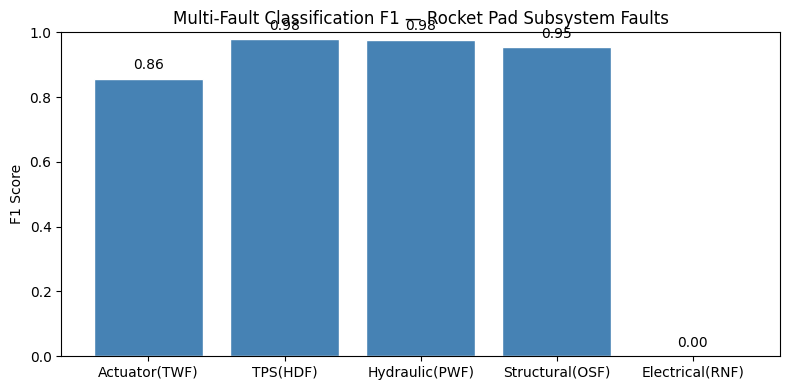

In [ ]:
from sklearn.multioutput import MultiOutputClassifier

# Only train on rows where at least one fault occurred
fault_mask = y_fault.sum(axis=1) > 0
X_fault = X_scaled[fault_mask]
y_fault_filtered = y_fault[fault_mask]

print(f'Fault samples: {fault_mask.sum()} / {len(y)}')
print('Fault type counts:')
print(y_fault_filtered.sum().rename({
    'TWF': 'Actuator (TWF)',
    'HDF': 'TPS (HDF)',
    'PWF': 'Hydraulic (PWF)',
    'OSF': 'Structural (OSF)',
    'RNF': 'Electrical (RNF)'
}))

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fault, y_fault_filtered, test_size=0.2, random_state=42
)

multi_model = MultiOutputClassifier(
    xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                       eval_metric='logloss', random_state=42),
    n_jobs=-1
)
multi_model.fit(Xf_train, yf_train)
yf_preds = multi_model.predict(Xf_test)

print()
print('=== Multi-Fault Classification — Per Fault Type ===')
fault_labels = ['Actuator(TWF)', 'TPS(HDF)', 'Hydraulic(PWF)', 'Structural(OSF)', 'Electrical(RNF)']
for i, label in enumerate(fault_labels):
    f1 = f1_score(yf_test.iloc[:, i], yf_preds[:, i], zero_division=0)
    acc = accuracy_score(yf_test.iloc[:, i], yf_preds[:, i])
    print(f'  {label:<22} Accuracy: {acc:.3f}  F1: {f1:.3f}')

# --- Visualise per-fault prediction performance ---
f1_scores = [f1_score(yf_test.iloc[:, i], yf_preds[:, i], zero_division=0)
             for i in range(5)]
plt.figure(figsize=(8, 4))
bars = plt.bar(fault_labels, f1_scores, color='steelblue', edgecolor='white')
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('Multi-Fault Classification F1 — Rocket Pad Subsystem Faults')
for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


##14 - Full Model Comparison

=== Model Comparison (Test Set) ===
Model                    Accuracy    ROC-AUC         F1
----------------------------------------------------------
Random Forest              0.9800     0.9713     0.7015
XGBoost                    0.9855     0.9716     0.7852
LightGBM                   0.9865     0.9691     0.7769
LSTM                       0.9658     0.4710     0.0000
Autoencoder                0.9275     0.6947     0.1989
Stacking Ensemble          0.9785     0.9740     0.7114

=== 5-Fold Cross-Validation AUC (tree models + stacking) ===
Model                    Mean AUC      Std
--------------------------------------------
Random Forest              0.9698   0.0054
XGBoost                    0.9738   0.0039
LightGBM                   0.9708   0.0064
Stacking Ensemble          0.9698   0.0064


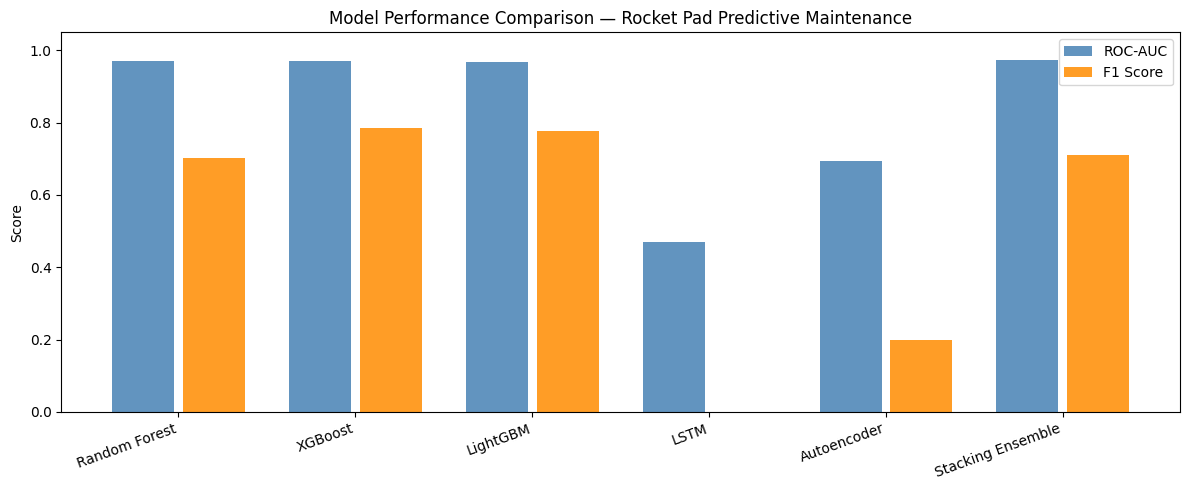

In [ ]:
results = {
    'Random Forest'    : {'Accuracy': accuracy_score(y_test, rf_preds_opt),
                          'ROC_AUC' : roc_auc_score(y_test, rf_probs),
                          'F1'      : f1_score(y_test, rf_preds_opt),
                          'probs'   : rf_probs, 'labels': y_test},
    'XGBoost'          : {'Accuracy': accuracy_score(y_test, xgb_preds_opt),
                          'ROC_AUC' : roc_auc_score(y_test, xgb_probs),
                          'F1'      : f1_score(y_test, xgb_preds_opt),
                          'probs'   : xgb_probs, 'labels': y_test},
    'LightGBM'         : {'Accuracy': accuracy_score(y_test, lgb_preds_opt),
                          'ROC_AUC' : roc_auc_score(y_test, lgb_probs),
                          'F1'      : f1_score(y_test, lgb_preds_opt),
                          'probs'   : lgb_probs, 'labels': y_test},
    'LSTM'             : {'Accuracy': accuracy_score(y_seq_test.astype(int), lstm_preds),
                          'ROC_AUC' : roc_auc_score(y_seq_test, lstm_probs),
                          'F1'      : f1_score(y_seq_test.astype(int), lstm_preds),
                          'probs'   : lstm_probs, 'labels': y_seq_test},
    'Autoencoder'      : {'Accuracy': accuracy_score(y_test, ae_preds),
                          'ROC_AUC' : roc_auc_score(y_test, ae_probs),
                          'F1'      : f1_score(y_test, ae_preds),
                          'probs'   : ae_probs, 'labels': y_test},
    'Stacking Ensemble': {'Accuracy': accuracy_score(y_test, stack_preds_opt),
                          'ROC_AUC' : roc_auc_score(y_test, stack_probs),
                          'F1'      : f1_score(y_test, stack_preds_opt),
                          'probs'   : stack_probs, 'labels': y_test},
}

# --- CV AUC summary ---
cv_summary = {
    'Random Forest'    : rf_cv_auc,
    'XGBoost'          : xgb_cv_auc,
    'LightGBM'         : lgb_cv_auc,
    'Stacking Ensemble': stack_cv_auc,
}

print('=== Model Comparison (Test Set) ===')
print(f'{"Model":<22} {"Accuracy":>10} {"ROC-AUC":>10} {"F1":>10}')
print('-' * 58)
for name, res in results.items():
    print(f'{name:<22} {res["Accuracy"]:>10.4f} {res["ROC_AUC"]:>10.4f} {res["F1"]:>10.4f}')

print()
print('=== 5-Fold Cross-Validation AUC (tree models + stacking) ===')
print(f'{"Model":<22} {"Mean AUC":>10} {"Std":>8}')
print('-' * 44)
for name, scores in cv_summary.items():
    print(f'{name:<22} {scores.mean():>10.4f} {scores.std():>8.4f}')

# --- Bar chart comparison ---
names = list(results.keys())
aucs  = [results[n]['ROC_AUC'] for n in names]
f1s   = [results[n]['F1']      for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, aucs, 0.35, label='ROC-AUC', color='steelblue',  alpha=0.85)
ax.bar(x + 0.2, f1s,  0.35, label='F1 Score', color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.legend()
ax.set_title('Model Performance Comparison — Rocket Pad Predictive Maintenance')
plt.tight_layout(); plt.show()


##15 - ROC Curves

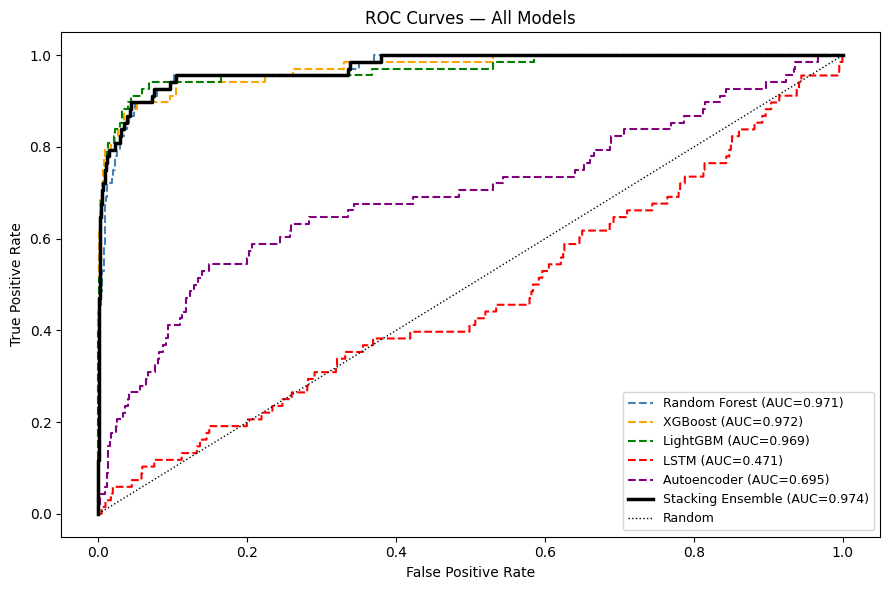

In [ ]:
plt.figure(figsize=(9, 6))
colors = ['steelblue', 'orange', 'green', 'red', 'purple', 'black']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
    auc = res['ROC_AUC']
    lw  = 2.5 if name == 'Stacking Ensemble' else 1.5
    ls  = '-'  if name == 'Stacking Ensemble' else '--'
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
             color=color, linewidth=lw, linestyle=ls)

plt.plot([0, 1], [0, 1], 'k:', label='Random', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


##16 - Confusion Matrices

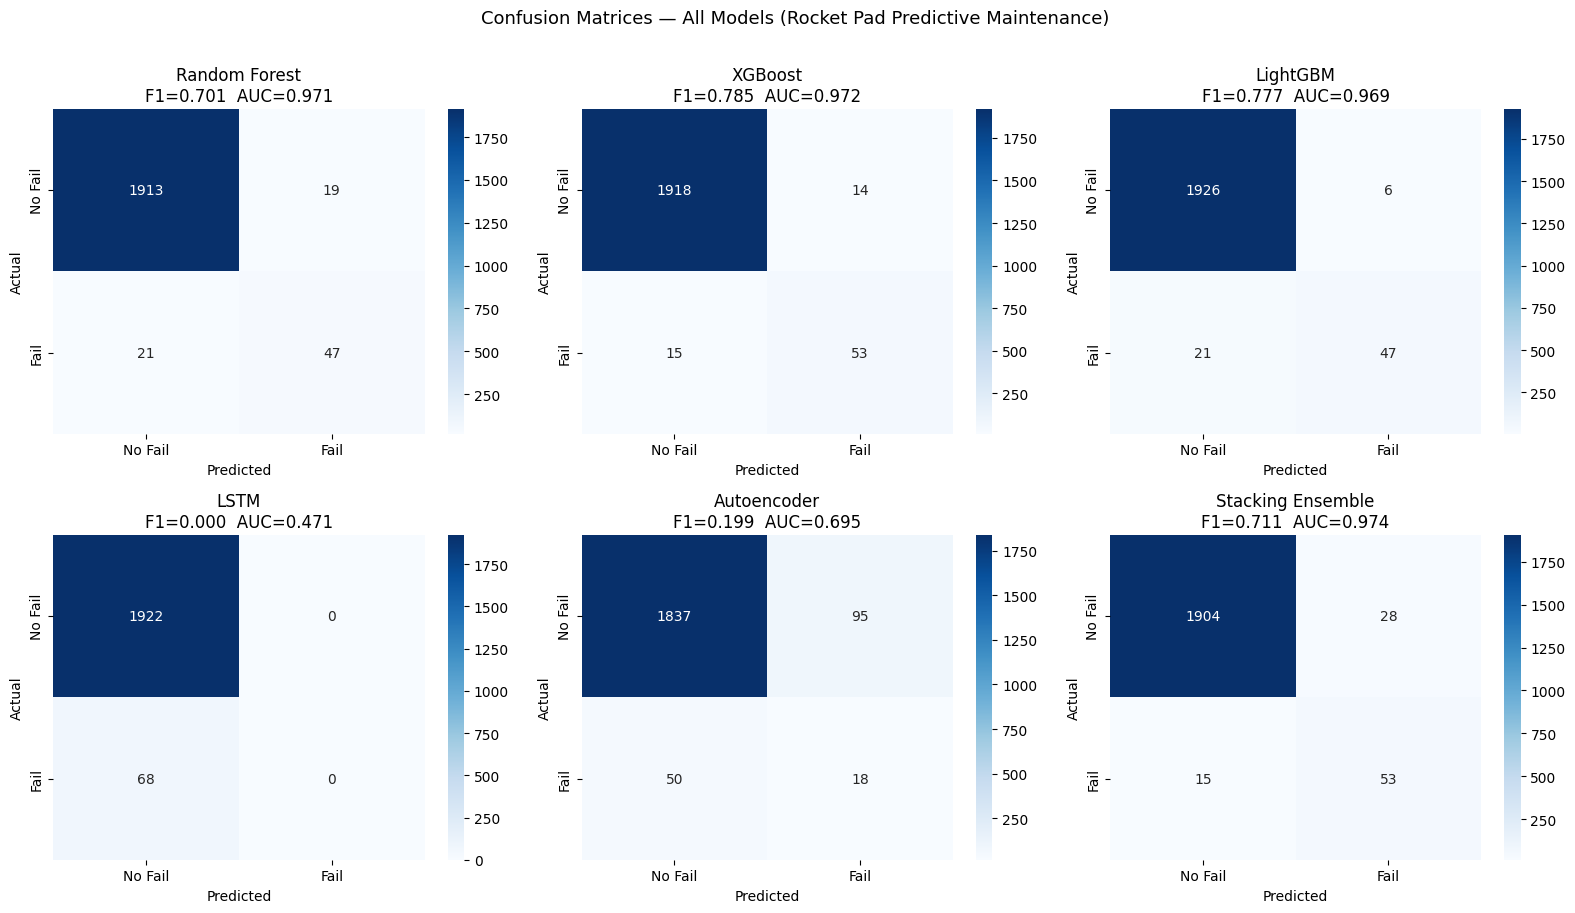

In [ ]:
classifier_preds = {
    'Random Forest'    : (y_test,                rf_preds_opt),
    'XGBoost'          : (y_test,                xgb_preds_opt),
    'LightGBM'         : (y_test,                lgb_preds_opt),
    'LSTM'             : (y_seq_test.astype(int), lstm_preds),
    'Autoencoder'      : (y_test,                ae_preds),
    'Stacking Ensemble': (y_test,                stack_preds_opt),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, (true, pred)) in zip(axes, classifier_preds.items()):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Fail', 'Fail'],
                yticklabels=['No Fail', 'Fail'])
    f1  = f1_score(true, pred, zero_division=0)
    auc = roc_auc_score(true, results[name]['probs'])
    ax.set_title(f'{name}\nF1={f1:.3f}  AUC={auc:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models (Rocket Pad Predictive Maintenance)',
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


##17 - SHAP Explainability

--- SHAP Summary Plot (Global Feature Importance) ---


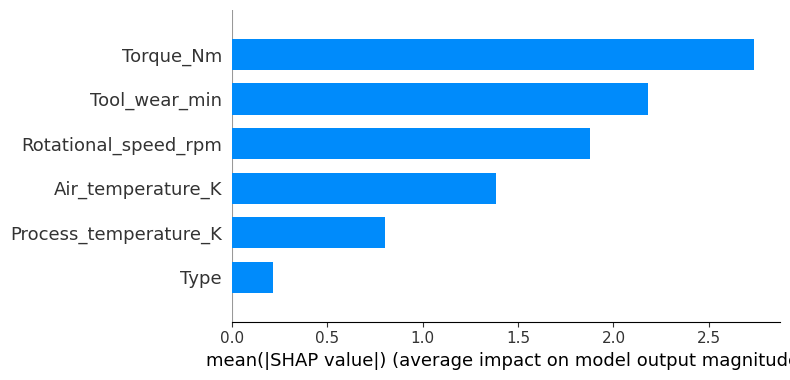


--- SHAP Beeswarm Plot (Impact Direction per Sample) ---


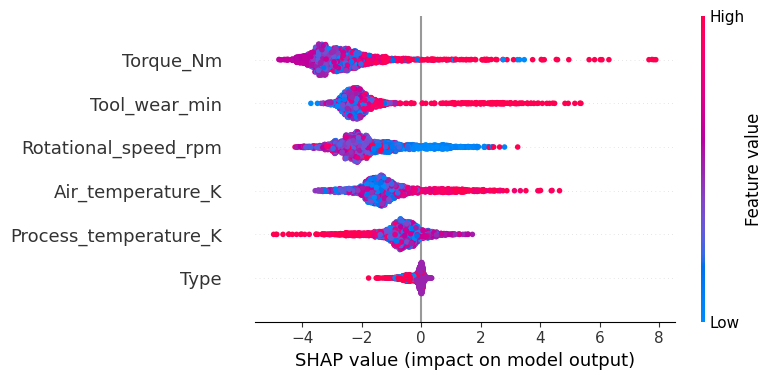


--- SHAP with Rocket Pad Sensor Labels ---


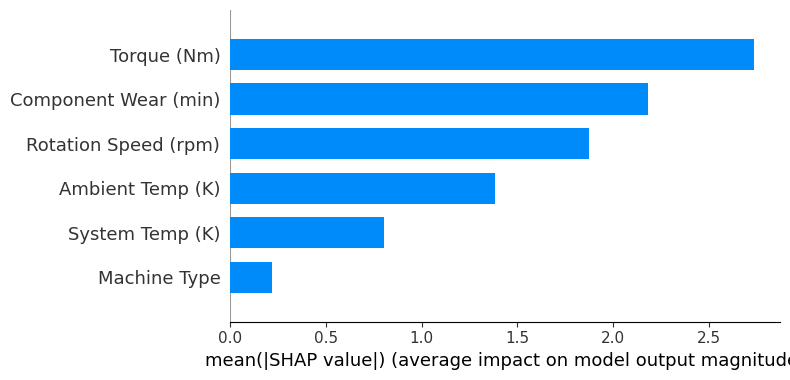

In [ ]:
# Explains which rocket pad sensor features drive failure predictions.
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print('--- SHAP Summary Plot (Global Feature Importance) ---')
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

print('\n--- SHAP Beeswarm Plot (Impact Direction per Sample) ---')
shap.summary_plot(shap_values, X_test, show=True)

# --- Rename columns to rocket pad analog for readability ---
X_test_named = X_test.copy()
rename_map = {
    'Air_temperature_K'     : 'Ambient Temp (K)',
    'Process_temperature_K' : 'System Temp (K)',
    'Rotational_speed_rpm'  : 'Rotation Speed (rpm)',
    'Torque_Nm'             : 'Torque (Nm)',
    'Tool_wear_min'         : 'Component Wear (min)',
    'Type'                  : 'Machine Type',
}
X_test_named = X_test_named.rename(columns=rename_map)
shap_named   = explainer.shap_values(X_test_named)

print('\n--- SHAP with Rocket Pad Sensor Labels ---')
shap.summary_plot(shap_named, X_test_named, plot_type='bar',
                  title='SHAP Feature Importance — Rocket Pad Sensor Analog', show=True)


##18 - Save All Models

In [ ]:
MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Tree-based classifiers
joblib.dump(rf,              os.path.join(MODEL_DIR, 'random_forest.pkl'))
joblib.dump(stacking_model,  os.path.join(MODEL_DIR, 'stacking_ensemble.pkl'))
joblib.dump(multi_model,     os.path.join(MODEL_DIR, 'multi_fault_classifier.pkl'))
joblib.dump(rul_model,       os.path.join(MODEL_DIR, 'rul_regressor.pkl'))
joblib.dump(scaler,          os.path.join(MODEL_DIR, 'scaler.pkl'))

# XGBoost and LightGBM native formats
xgb_model.save_model(os.path.join(MODEL_DIR, 'xgboost_model.json'))
lgb_model.booster_.save_model(os.path.join(MODEL_DIR, 'lightgbm_model.txt'))

# PyTorch models
torch.save(lstm.state_dict(), os.path.join(MODEL_DIR, 'lstm_model.pt'))
torch.save(ae.state_dict(),   os.path.join(MODEL_DIR, 'autoencoder.pt'))

# Save optimal thresholds
joblib.dump(optimal_thresholds, os.path.join(MODEL_DIR, 'optimal_thresholds.pkl'))

print('All models saved to:', MODEL_DIR)
for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f'  {f:<40} {size:>8.1f} KB')


All models saved to: saved_models
  autoencoder.pt                                5.6 KB
  lightgbm_model.txt                         1100.1 KB
  lstm_model.pt                               214.9 KB
  multi_fault_classifier.pkl                  899.6 KB
  optimal_thresholds.pkl                        0.2 KB
  random_forest.pkl                          6372.2 KB
  rul_regressor.pkl                          1204.0 KB
  scaler.pkl                                    1.1 KB
  stacking_ensemble.pkl                      8603.6 KB
  xgboost_model.json                         1636.9 KB
